In [1]:
import pandas as pd
import sys
from pathlib import Path
from utils import *
from utils.helper_classification import *
# add the directory to the path
sys.path.insert(0, str(Path.cwd()))

# FAIRNESS RESULTS PLOT MLEF

run this section to reproduce **figure 4** fairness graphs

In [2]:
OUTCOME_CONFIG = {
    'OS 24': {
        'outcome': 'OS_24',
        'outcome_name': 'OS 24'
    },
     'OS 6': {
        'outcome': 'OS_6',
        'outcome_name': 'OS 6'
    },
    'DCR': {
        'outcome': 'DCR',              
        'outcome_name': 'DCR'         
    }
    
}

In [3]:
# Predictions are loaded from: mlef_pipeline/results/{outcome}/C23/RWD/prediction_TEST.csv

# Base path where MLEF folder is located
BASE_PATH = 'mlef_pipeline/results'

# These will be computed automatically from the data
PATIENTS_PER_OUTCOME = {}
OUTCOME_THRESHOLDS_TPR = {}
OUTCOME_THRESHOLDS_FPR = {}

In [4]:
# Run analysis for all outcomes
all_results = {}

for outcome_display_name, config in OUTCOME_CONFIG.items():
    results = analyze_outcome_fairness(
        outcome=config['outcome'],
        outcome_name=config['outcome_name'],
        base_path=BASE_PATH,
        n_perms=1000,
        random_state=42
    )
    all_results[outcome_display_name] = results
    
    # Populate thresholds and patient counts automatically
    OUTCOME_THRESHOLDS_TPR[outcome_display_name] = results['threshold_tpr']
    OUTCOME_THRESHOLDS_FPR[outcome_display_name] = results['threshold_fpr']
    PATIENTS_PER_OUTCOME[outcome_display_name] = results['patients_per_center']

print("\n" + "="*60)
print("Analysis completed for all outcomes!")
print("="*60)
print("\nComputed Thresholds:")
print(f"  TPR: {OUTCOME_THRESHOLDS_TPR}")
print(f"  FPR: {OUTCOME_THRESHOLDS_FPR}")
print(f"\nPatients per outcome (by center):")
for outcome, counts in PATIENTS_PER_OUTCOME.items():
    print(f"  {outcome}: {counts}")


Analyzing OS 24 (MLEF)

Loaded predictions for OS_24 (MLEF):
  Samples: 226
  Columns in test data: 2 (CENTER, SEX)
  Subject order preserved: True
Overall Test Performance:
  AUC: 0.739
  TPR (threshold): 0.850
  FPR (threshold): 0.500

Analyzing fairness by center...
Patients per center: {'INT': 97, 'GHD': 63, 'VHIO': 29, 'SZMC': 20, 'MH': 17}
Patients per sex: {1: 141, 0: 85}


Sex-based fairness analysis (test set)...
  TPR - Female: 0.960, Male: 0.771, p=0.0539
  FPR - Female: 0.550, Male: 0.472, p=0.3407

Center-based fairness analysis...


  TPR omnibus p-value: 0.1239
  FPR omnibus p-value: 0.3876

Analyzing OS 6 (MLEF)

Loaded predictions for OS_6 (MLEF):
  Samples: 259
  Columns in test data: 2 (CENTER, SEX)
  Subject order preserved: True
Overall Test Performance:
  AUC: 0.692
  TPR (threshold): 0.648
  FPR (threshold): 0.364

Analyzing fairness by center...
Patients per center: {'INT': 101, 'GHD': 65, 'SZMC': 36, 'VHIO': 31, 'MH': 26}
Patients per sex: {1: 166, 0: 93}


Sex-based fairness analysis (test set)...
  TPR - Female: 0.714, Male: 0.613, p=0.2038
  FPR - Female: 0.433, Male: 0.319, p=0.3177

Center-based fairness analysis...
  TPR omnibus p-value: 0.0160
  FPR omnibus p-value: 0.0340

Analyzing DCR (MLEF)

Loaded predictions for DCR (MLEF):
  Samples: 273
  Columns in test data: 2 (CENTER, SEX)
  Subject order preserved: True
Overall Test Performance:
  AUC: 0.714
  TPR (threshold): 0.722
  FPR (threshold): 0.442

Analyzing fairness by center...
Patients per center: {'INT': 101, 'GHD': 65, 'SZMC': 41, 'MH':

In [5]:
# Create summary tables
sex_fairness, center_fairness, pairwise_tpr, pairwise_fpr = create_fairness_summary(all_results)

print("Sex-based fairness summary:")
display(sex_fairness)

print("\nCenter-based fairness summary:")
display(center_fairness)

Sex-based fairness summary:


,Metric,Sex,Value,CI,p-value,outcome
0,TPR,Female,0.960000,"(0.88, 1.0)",0.053946,OS 24
1,TPR,Male,0.771429,"(0.63, 0.91)",0.053946,OS 24
2,FPR,Female,0.550000,"(0.43, 0.68)",0.340659,OS 24
3,FPR,Male,0.471698,"(0.37, 0.57)",0.340659,OS 24
4,TPR,Female,0.714286,"(0.6, 0.83)",0.203796,OS 6
5,TPR,Male,0.613445,"(0.53, 0.71)",0.203796,OS 6
6,FPR,Female,0.433333,"(0.27, 0.6)",0.317682,OS 6
7,FPR,Male,0.319149,"(0.19, 0.45)",0.317682,OS 6
8,TPR,Female,0.796610,"(0.68, 0.9)",0.150849,DCR
9,TPR,Male,0.681818,"(0.59, 0.77)",0.150849,DCR



Center-based fairness summary:


,TPR,TPR_ci_lower,TPR_ci_upper,FPR,FPR_ci_lower,FPR_ci_upper,outcome
center,,,,,,,
GHD,0.875000,0.62,1.00,0.545455,0.40,0.67,OS 24
GHD,0.619048,0.48,0.74,0.565217,0.35,0.74,OS 6
GHD,0.727273,0.58,0.88,0.531250,0.34,0.69,DCR
INT,0.833333,0.70,0.97,0.417910,0.30,0.54,OS 24
INT,0.578125,0.45,0.69,0.270270,0.14,0.41,OS 6
INT,0.631579,0.51,0.75,0.318182,0.18,0.45,DCR
MH,1.000000,1.00,1.00,0.666667,0.33,0.89,OS 24
MH,0.958333,0.88,1.00,0.500000,0.00,1.00,OS 6
MH,0.964286,0.89,1.00,0.714286,0.29,1.00,DCR


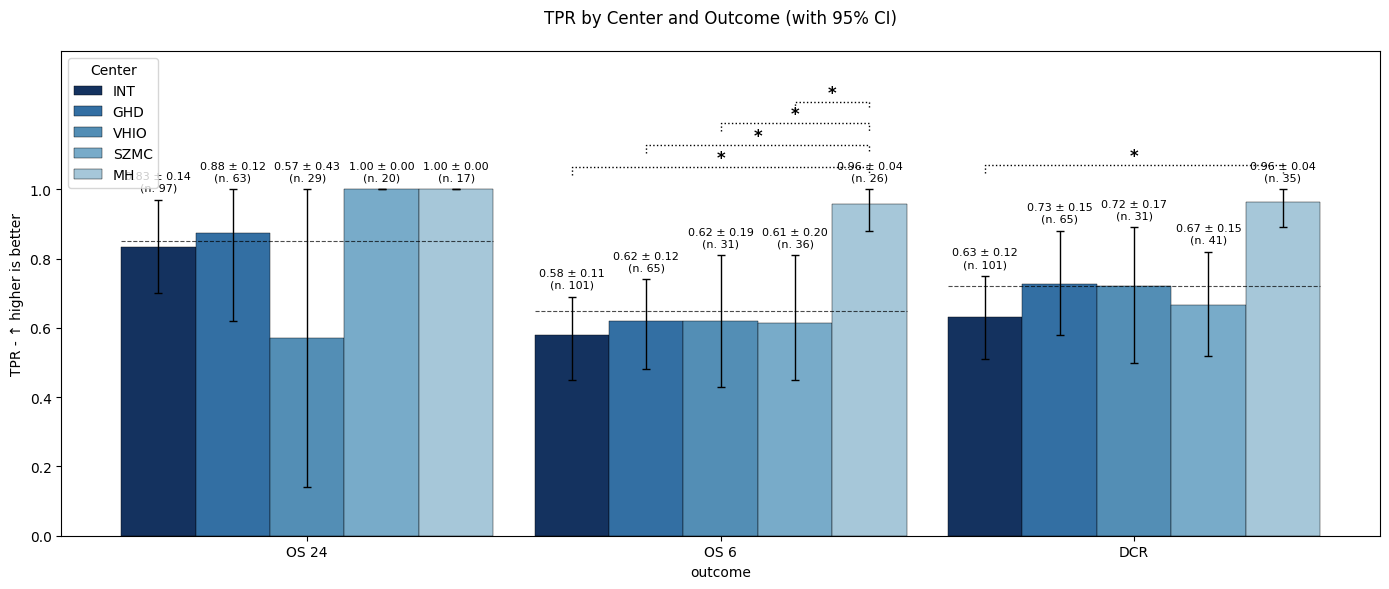

In [ ]:
# Plot TPR by center
plot_fairness_by_center(
    center_fairness=center_fairness,
    pairwise_tpr=pairwise_tpr,
    pairwise_fpr=pairwise_fpr,
    metric='TPR',
    patients_per_outcome=PATIENTS_PER_OUTCOME,
    outcome_thresholds=OUTCOME_THRESHOLDS_TPR
)

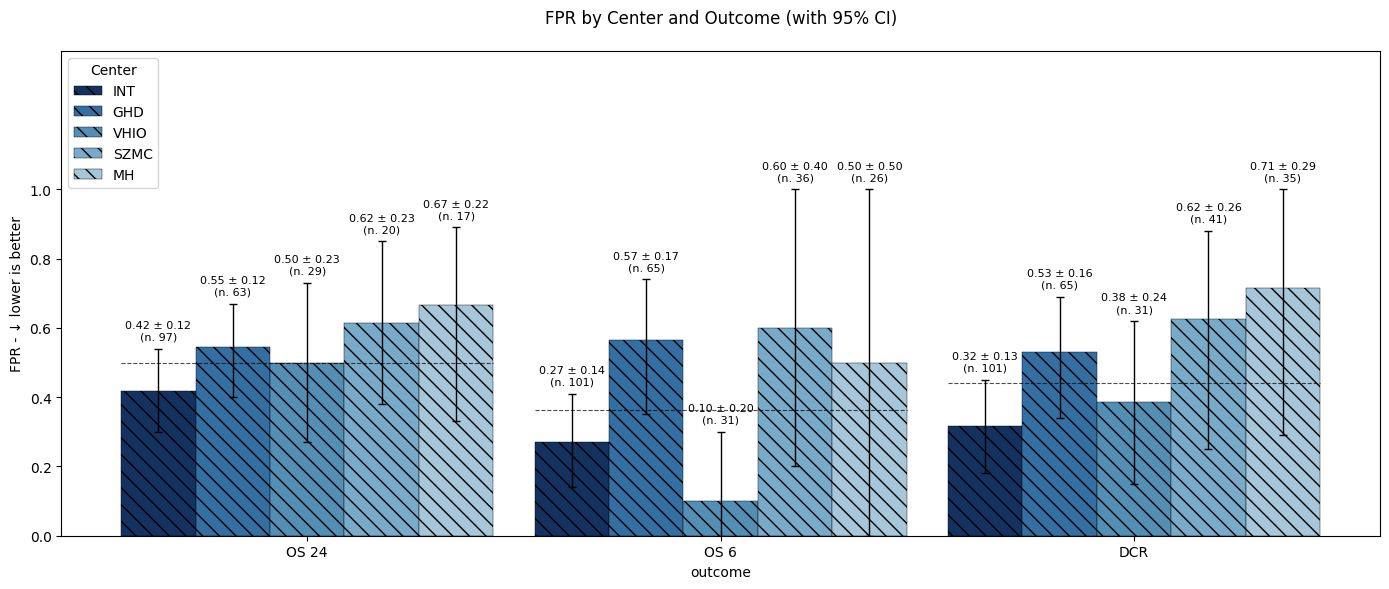

In [ ]:
# Plot FPR by center
plot_fairness_by_center(
    center_fairness=center_fairness,
    pairwise_tpr=pairwise_tpr,
    pairwise_fpr=pairwise_fpr,
    metric='FPR',
    patients_per_outcome=PATIENTS_PER_OUTCOME,
    outcome_thresholds=OUTCOME_THRESHOLDS_FPR
)

Patients per sex:
  OS 24: {'Female': 85, 'Male': 141}
  OS 6: {'Female': 93, 'Male': 166}
  DCR: {'Female': 98, 'Male': 175}


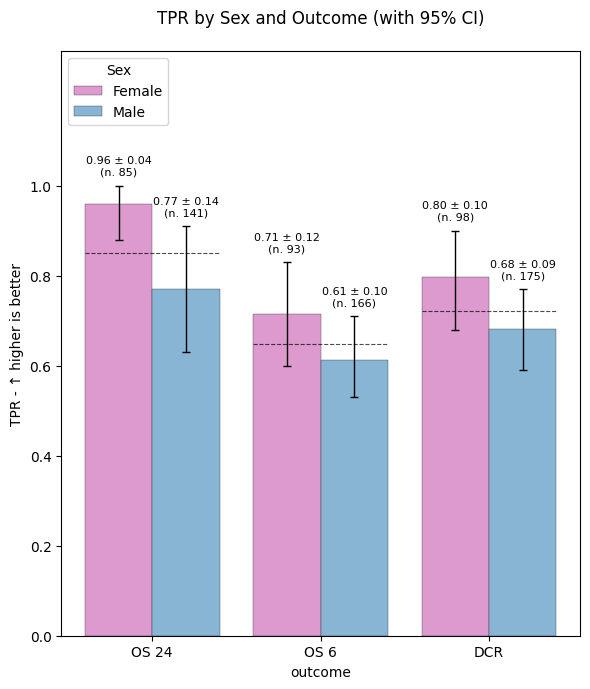

In [ ]:
# Compute sex patient counts from results
sex_patients = {}
for outcome_name, results in all_results.items():
    sex_counts = results['patients_per_sex']
    # Map numeric values to labels (assuming 0=Female, 1=Male)
    sex_patients[outcome_name] = {
        'Female': sex_counts.get(0, 0),
        'Male': sex_counts.get(1, 0)
    }

print("Patients per sex:")
for outcome, counts in sex_patients.items():
    print(f"  {outcome}: {counts}")

# Plot TPR by sex (test set)
plot_fairness_by_group(
    fairness_df=sex_fairness,
    metric='TPR',
    group_col='Sex',
    patients_per_outcome=sex_patients,
    outcome_thresholds=OUTCOME_THRESHOLDS_TPR
)

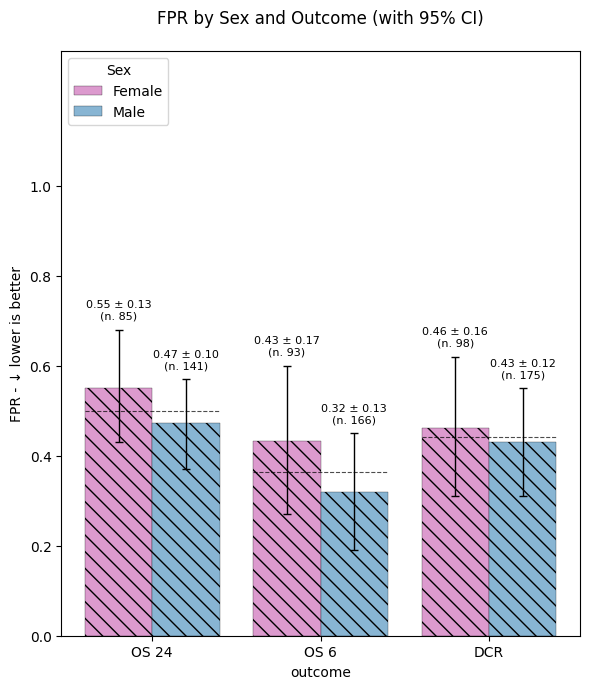

In [ ]:
# Plot FPR by sex (test set)
plot_fairness_by_group(
    fairness_df=sex_fairness,
    metric='FPR',
    group_col='Sex',
    patients_per_outcome=sex_patients,
    outcome_thresholds=OUTCOME_THRESHOLDS_FPR
)

In [ ]:
# Analyze race and sex fairness for each outcome (EXVAL)
OUTCOME_THRESHOLDS_TPR = {}
OUTCOME_THRESHOLDS_FPR = {}
exval_results = {}

for outcome_display_name, config in OUTCOME_CONFIG.items():
    results = analyze_exval_outcome_fairness_by_race(
        outcome=config['outcome'],
        outcome_name=config['outcome_name'],
        base_path=BASE_PATH,
        n_perms=1000,
        random_state=42
    )
    exval_results[outcome_display_name] = results
    OUTCOME_THRESHOLDS_TPR[outcome_display_name] = results.get('threshold_tpr', None)
    OUTCOME_THRESHOLDS_FPR[outcome_display_name] = results.get('threshold_fpr', None)

# Create summary
race_fairness_summary, sex_fairness_summary = create_race_fairness_summary(exval_results)

print("Race-based fairness summary (EXVAL):")
display(race_fairness_summary)

print("\nSex-based fairness summary (EXVAL):")
display(sex_fairness_summary)


Analyzing EXVAL Race & Sex Fairness for OS 24

Loaded EXVAL predictions for OS_24 (MLEF):
  Samples: 190
  Columns in exval data: 2 (SEX, RACE)
  Subject order preserved: True

Overall EXVAL Performance (filtered by race):
  TPR (threshold): 0.960
  FPR (threshold): 0.878

Patients per race: {'WHITE': 91, 'BLACK OR AFRICAN AMERICAN': 90}
Patients per sex: {0: 119, 1: 71}


Race-based fairness analysis (EXVAL set)...
  TPR - WHITE: 0.946, BLACK OR AFRICAN AMERICAN: 0.973, p=1.0000
  FPR - WHITE: 0.870, BLACK OR AFRICAN AMERICAN: 0.887, p=1.0000

Sex-based fairness analysis (EXVAL set)...
  TPR - Female: 0.960, Male: 0.960, p=1.0000
  FPR - Female: 0.884, Male: 0.870, p=1.0000

Analyzing EXVAL Race & Sex Fairness for OS 6

Loaded EXVAL predictions for OS_6 (MLEF):
  Samples: 240
  Columns in exval data: 2 (SEX, RACE)
  Subject order preserved: True

Overall EXVAL Performance (filtered by race):
  TPR (threshold): 0.407
  FPR (threshold): 0.207

Patients per race: {'BLACK OR AFRICAN AMER

,Metric,Race,Value,CI,p-value,outcome
0,TPR,WHITE,0.945946,"(0.86, 1.0)",1.000000,OS 24
1,TPR,BLACK OR AFRICAN AMERICAN,0.972973,"(0.92, 1.0)",1.000000,OS 24
2,FPR,WHITE,0.870370,"(0.76, 0.94)",1.000000,OS 24
3,FPR,BLACK OR AFRICAN AMERICAN,0.886792,"(0.79, 0.96)",1.000000,OS 24
4,TPR,WHITE,0.435294,"(0.33, 0.54)",0.426573,OS 6
5,TPR,BLACK OR AFRICAN AMERICAN,0.377778,"(0.28, 0.47)",0.426573,OS 6
6,FPR,WHITE,0.240000,"(0.08, 0.4)",1.000000,OS 6
7,FPR,BLACK OR AFRICAN AMERICAN,0.214286,"(0.07, 0.36)",1.000000,OS 6
8,TPR,WHITE,0.434783,"(0.32, 0.55)",0.591409,DCR
9,TPR,BLACK OR AFRICAN AMERICAN,0.492308,"(0.37, 0.6)",0.591409,DCR



Sex-based fairness summary (EXVAL):


,Metric,Sex,Value,CI,p-value,outcome
0,TPR,Female,0.960000,"(0.9, 1.0)",1.000000,OS 24
1,TPR,Male,0.960000,"(0.88, 1.0)",1.000000,OS 24
2,FPR,Female,0.884058,"(0.81, 0.96)",1.000000,OS 24
3,FPR,Male,0.869565,"(0.78, 0.96)",1.000000,OS 24
4,TPR,Female,0.409091,"(0.31, 0.5)",1.000000,OS 6
5,TPR,Male,0.402778,"(0.29, 0.53)",1.000000,OS 6
6,FPR,Female,0.176471,"(0.06, 0.32)",0.540460,OS 6
7,FPR,Male,0.250000,"(0.08, 0.42)",0.540460,OS 6
8,TPR,Female,0.512195,"(0.4, 0.62)",0.224775,DCR
9,TPR,Male,0.400000,"(0.27, 0.53)",0.224775,DCR


Patients per race (EXVAL):
  OS 24: {'WHITE': 91, 'BLACK OR AFRICAN AMERICAN': 90}
  OS 6: {'BLACK OR AFRICAN AMERICAN': 118, 'WHITE': 110}
  DCR: {'BLACK OR AFRICAN AMERICAN': 125, 'WHITE': 113}

Patients per sex (EXVAL):
  OS 24: {'Female': 119, 'Male': 71}
  OS 6: {'Female': 144, 'Male': 96}
  DCR: {'Female': 148, 'Male': 103}


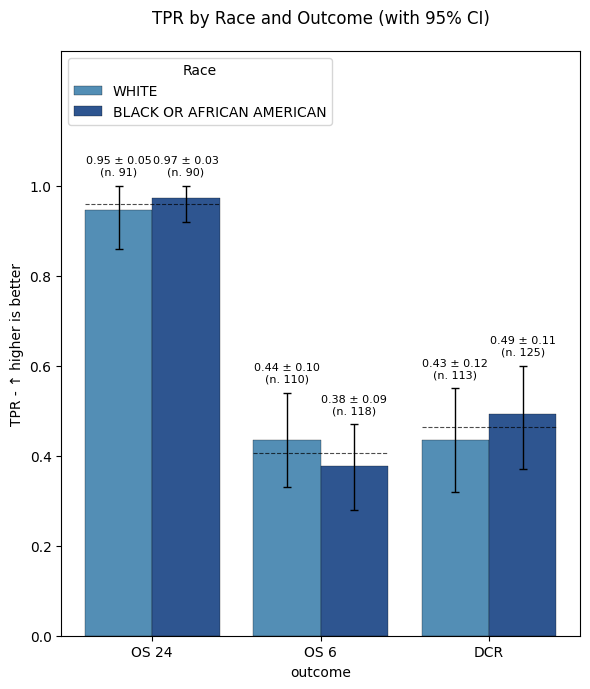

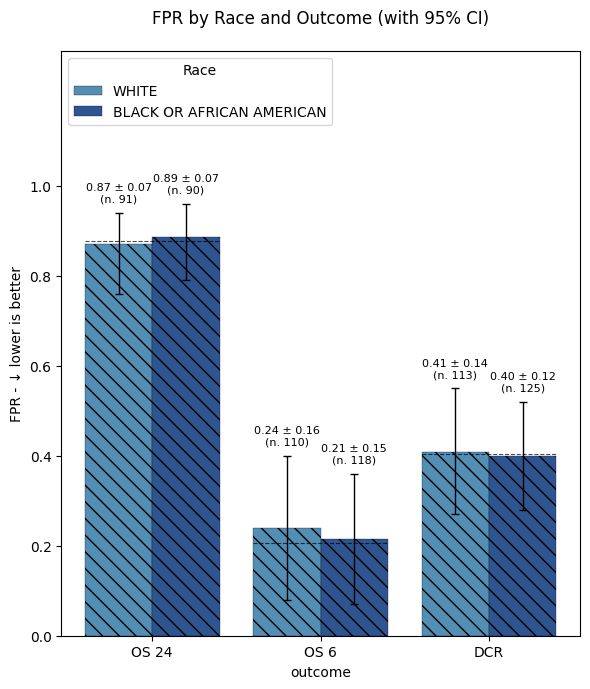

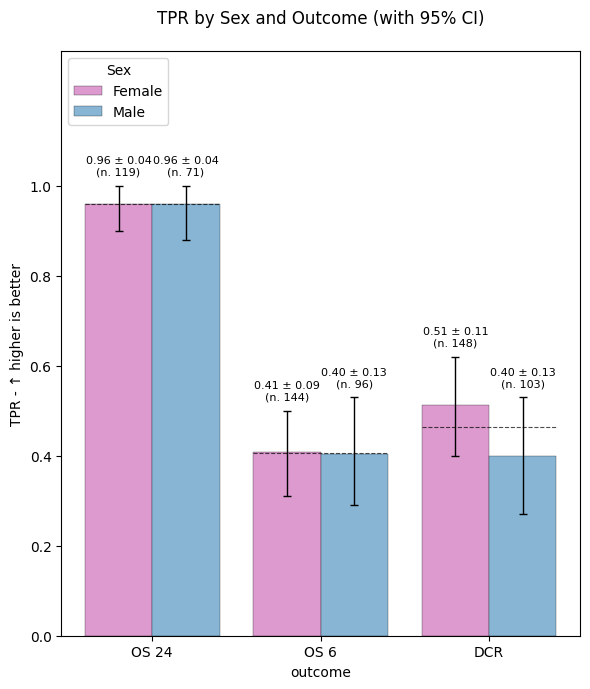

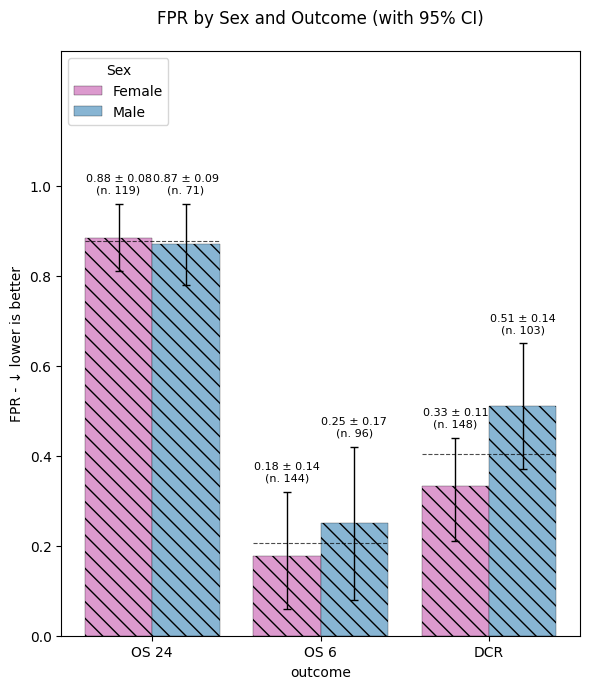

In [ ]:
# Compute patient counts from results
exval_patients_race = {}
exval_patients_sex = {}

for outcome_name, results in exval_results.items():
    if results is None: continue
    exval_patients_race[outcome_name] = results['patients_per_race']
    exval_patients_sex[outcome_name] = results['patients_per_sex']

print("Patients per race (EXVAL):")
for outcome, counts in exval_patients_race.items():
    print(f"  {outcome}: {counts}")



sex_map = {0: "Female", 1: "Male"}

for outcome in exval_patients_sex:
    exval_patients_sex[outcome] = {
        sex_map[k]: v for k, v in exval_patients_sex[outcome].items()
    }
    
print("\nPatients per sex (EXVAL):")
for outcome, counts in exval_patients_sex.items():
    print(f"  {outcome}: {counts}")
# Plot TPR by race (EXVAL)
plot_fairness_by_group(
    fairness_df=race_fairness_summary,
    metric='TPR',
    group_col='Race',
    patients_per_outcome=exval_patients_race,
    outcome_thresholds=OUTCOME_THRESHOLDS_TPR
)

# Plot FPR by race (EXVAL)
plot_fairness_by_group(
    fairness_df=race_fairness_summary,
    metric='FPR',
    group_col='Race',
    patients_per_outcome=exval_patients_race,
    outcome_thresholds=OUTCOME_THRESHOLDS_FPR
)

# Plot TPR by sex (EXVAL)
plot_fairness_by_group(
    fairness_df=sex_fairness_summary,
    metric='TPR',
    group_col='Sex',
    patients_per_outcome=exval_patients_sex,
    outcome_thresholds=OUTCOME_THRESHOLDS_TPR
)

# Plot FPR by sex (EXVAL)
plot_fairness_by_group(
    fairness_df=sex_fairness_summary,
    metric='FPR',
    group_col='Sex',
    patients_per_outcome=exval_patients_sex,
    outcome_thresholds=OUTCOME_THRESHOLDS_FPR
)

# FARINESS RESULTS PLOT DLIF

In [ ]:
OUTCOME_CONFIG = {
    'OS 24': {
        'outcome': 'os_months_24',
        'outcome_name': 'OS 24'
    },
     'OS 6': {
        'outcome': 'os_months_6',
        'outcome_name': 'OS 6'
    },
    'DCR': {
        'outcome': 'DCR',              
        'outcome_name': 'DCR'         
    }
    
}

In [ ]:
# Base path where MLEF folder is located
BASE_PATH = 'dlif_pipeline/results'

# These will be computed automatically from the data
PATIENTS_PER_OUTCOME = {}
OUTCOME_THRESHOLDS_TPR = {}
OUTCOME_THRESHOLDS_FPR = {}

In [ ]:
# Run analysis for all outcomes
all_results = {}

for outcome_display_name, config in OUTCOME_CONFIG.items():
    results = analyze_outcome_fairness(
        outcome=config['outcome'],
        architecture = "DLIF",
        outcome_name=config['outcome_name'],
        base_path=BASE_PATH,
        n_perms=1000,
        random_state=42
    )
    all_results[outcome_display_name] = results
    
    # Populate thresholds and patient counts automatically
    OUTCOME_THRESHOLDS_TPR[outcome_display_name] = results['threshold_tpr']
    OUTCOME_THRESHOLDS_FPR[outcome_display_name] = results['threshold_fpr']
    PATIENTS_PER_OUTCOME[outcome_display_name] = results['patients_per_center']

print("\n" + "="*60)
print("Analysis completed for all outcomes!")
print("="*60)
print("\nComputed Thresholds:")
print(f"  TPR: {OUTCOME_THRESHOLDS_TPR}")
print(f"  FPR: {OUTCOME_THRESHOLDS_FPR}")
print(f"\nPatients per outcome (by center):")
for outcome, counts in PATIENTS_PER_OUTCOME.items():
    print(f"  {outcome}: {counts}")


Analyzing OS 24 (DLIF)

Loaded predictions for os_months_24 (DLIF):
  Samples: 226
  Columns in test data: 2 (CENTER, SEX)
  Subject order preserved: True
Overall Test Performance:
  AUC: 0.630
  TPR (threshold): 0.917
  FPR (threshold): 0.657

Analyzing fairness by center...
Patients per center: {'INT': 97, 'GHD': 63, 'VHIO': 29, 'SZMC': 20, 'MH': 17}
Patients per sex: {1: 141, 0: 85}


Sex-based fairness analysis (test set)...
  TPR - Female: 1.000, Male: 0.857, p=0.0769
  FPR - Female: 0.767, Male: 0.594, p=0.0340

Center-based fairness analysis...
  TPR omnibus p-value: 0.1229
  FPR omnibus p-value: 0.0859

Analyzing OS 6 (DLIF)

Loaded predictions for os_months_6 (DLIF):
  Samples: 259
  Columns in test data: 2 (CENTER, SEX)
  Subject order preserved: True
Overall Test Performance:
  AUC: 0.663
  TPR (threshold): 0.742
  FPR (threshold): 0.416

Analyzing fairness by center...
Patients per center: {'INT': 101, 'GHD': 65, 'SZMC': 36, 'VHIO': 31, 'MH': 26}
Patients per sex: {1: 166,

In [ ]:
# Create summary tables
sex_fairness, center_fairness, pairwise_tpr, pairwise_fpr = create_fairness_summary(all_results)

print("Sex-based fairness summary:")
display(sex_fairness)

print("\nCenter-based fairness summary:")
display(center_fairness)

Sex-based fairness summary:


,Metric,Sex,Value,CI,p-value,outcome
0,TPR,Female,1.000000,"(1.0, 1.0)",0.076923,OS 24
1,TPR,Male,0.857143,"(0.74, 0.94)",0.076923,OS 24
2,FPR,Female,0.766667,"(0.65, 0.87)",0.033966,OS 24
3,FPR,Male,0.594340,"(0.5, 0.68)",0.033966,OS 24
4,TPR,Female,0.714286,"(0.63, 0.8)",0.263736,OS 6
5,TPR,Male,0.793651,"(0.68, 0.89)",0.263736,OS 6
6,FPR,Female,0.382979,"(0.26, 0.53)",0.500500,OS 6
7,FPR,Male,0.466667,"(0.3, 0.63)",0.500500,OS 6
8,TPR,Female,0.863636,"(0.8, 0.93)",0.211788,DCR
9,TPR,Male,0.932203,"(0.86, 0.98)",0.211788,DCR



Center-based fairness summary:


,TPR,TPR_ci_lower,TPR_ci_upper,FPR,FPR_ci_lower,FPR_ci_upper,outcome
center,,,,,,,
GHD,1.000000,1.00,1.00,0.727273,0.62,0.84,OS 24
GHD,0.619048,0.48,0.76,0.565217,0.35,0.78,OS 6
GHD,0.848485,0.73,0.97,0.656250,0.50,0.81,DCR
INT,0.900000,0.80,1.00,0.567164,0.45,0.69,OS 24
INT,0.718750,0.61,0.83,0.297297,0.16,0.43,OS 6
INT,0.842105,0.75,0.93,0.613636,0.48,0.75,DCR
MH,1.000000,1.00,1.00,0.666667,0.33,0.89,OS 24
MH,0.833333,0.67,0.96,0.500000,0.00,1.00,OS 6
MH,0.964286,0.89,1.00,1.000000,1.00,1.00,DCR


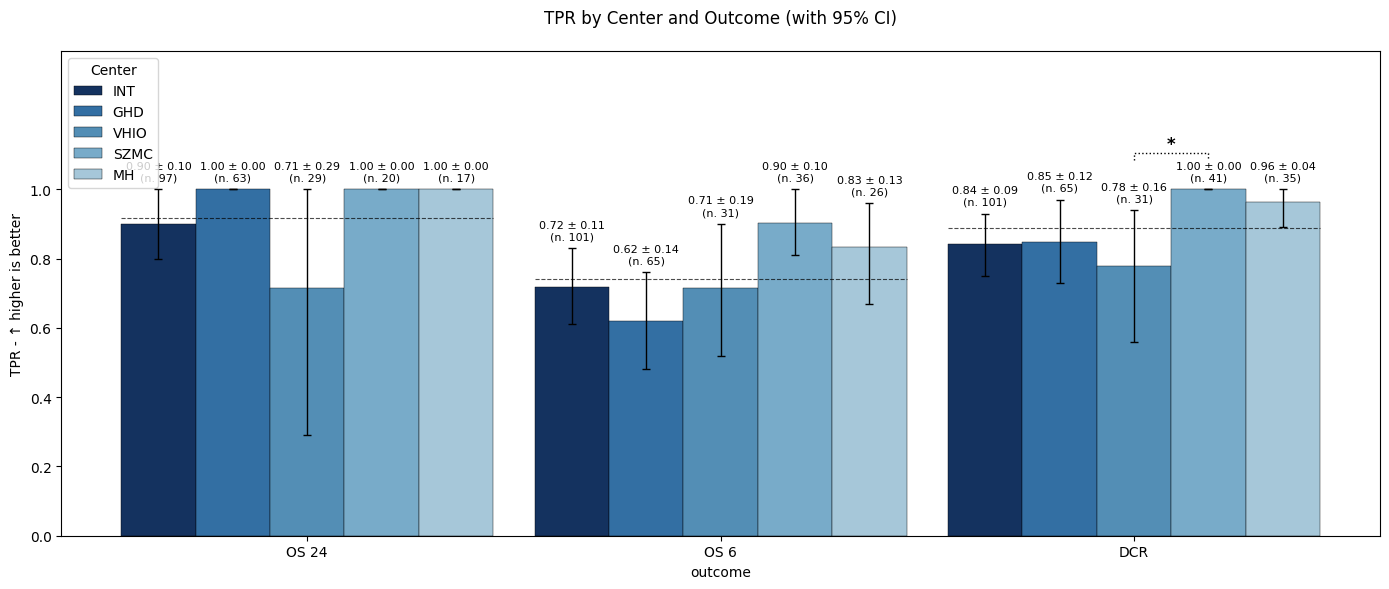

In [ ]:
# Plot TPR by center
plot_fairness_by_center(
    center_fairness=center_fairness,
    pairwise_tpr=pairwise_tpr,
    pairwise_fpr=pairwise_fpr,
    metric='TPR',
    patients_per_outcome=PATIENTS_PER_OUTCOME,
    outcome_thresholds=OUTCOME_THRESHOLDS_TPR
)

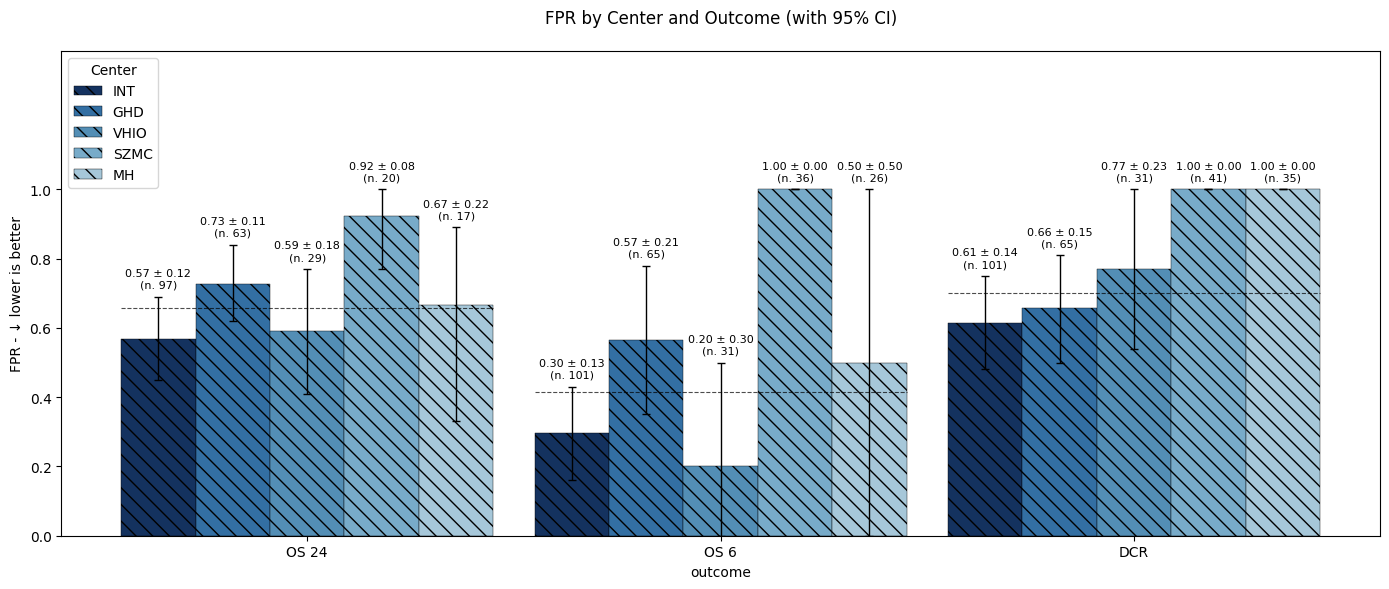

In [ ]:
# Plot FPR by center
plot_fairness_by_center(
    center_fairness=center_fairness,
    pairwise_tpr=pairwise_tpr,
    pairwise_fpr=pairwise_fpr,
    metric='FPR',
    patients_per_outcome=PATIENTS_PER_OUTCOME,
    outcome_thresholds=OUTCOME_THRESHOLDS_FPR
)

Patients per sex:
  OS 24: {'Female': 85, 'Male': 141}
  OS 6: {'Female': 93, 'Male': 166}
  DCR: {'Female': 98, 'Male': 175}


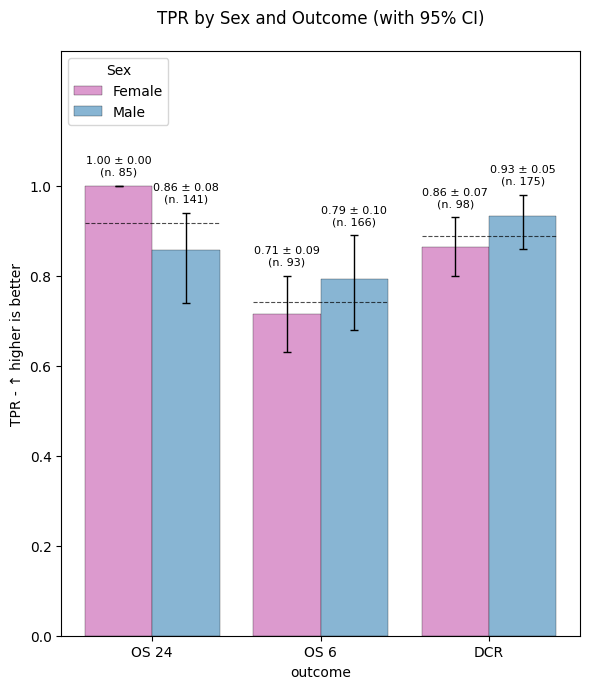

In [ ]:
# Compute sex patient counts from results
sex_patients = {}
for outcome_name, results in all_results.items():
    sex_counts = results['patients_per_sex']
    # Map numeric values to labels (assuming 0=Female, 1=Male)
    sex_patients[outcome_name] = {
        'Female': sex_counts.get(0, 0),
        'Male': sex_counts.get(1, 0)
    }

print("Patients per sex:")
for outcome, counts in sex_patients.items():
    print(f"  {outcome}: {counts}")

# Plot TPR by sex (test set)
plot_fairness_by_group(
    fairness_df=sex_fairness,
    metric='TPR',
    group_col='Sex',
    patients_per_outcome=sex_patients,
    outcome_thresholds=OUTCOME_THRESHOLDS_TPR
)

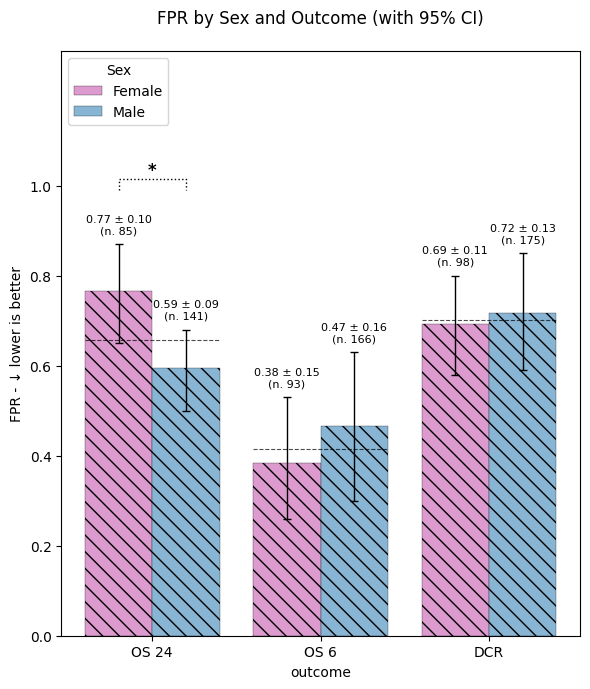

In [ ]:
# Plot FPR by sex (test set)
plot_fairness_by_group(
    fairness_df=sex_fairness,
    metric='FPR',
    group_col='Sex',
    patients_per_outcome=sex_patients,
    outcome_thresholds=OUTCOME_THRESHOLDS_FPR
)

In [ ]:
# Analyze race and sex fairness for each outcome (EXVAL)
OUTCOME_THRESHOLDS_TPR = {}
OUTCOME_THRESHOLDS_FPR = {}
exval_results = {}

for outcome_display_name, config in OUTCOME_CONFIG.items():
    results = analyze_exval_outcome_fairness_by_race(
        outcome=config['outcome'],
        outcome_name=config['outcome_name'],
        architecture='DLIF',
        base_path=BASE_PATH,
        n_perms=1000,
        random_state=42
    )
    exval_results[outcome_display_name] = results
    OUTCOME_THRESHOLDS_TPR[outcome_display_name] = results.get('threshold_tpr', None)
    OUTCOME_THRESHOLDS_FPR[outcome_display_name] = results.get('threshold_fpr', None)

# Create summary
race_fairness_summary, sex_fairness_summary = create_race_fairness_summary(exval_results)

print("Race-based fairness summary (EXVAL):")
display(race_fairness_summary)

print("\nSex-based fairness summary (EXVAL):")
display(sex_fairness_summary)


Analyzing EXVAL Race & Sex Fairness for OS 24

Loaded EXVAL predictions for os_months_24 (DLIF):
  Samples: 190
  Columns in exval data: 2 (SEX, RACE)
  Subject order preserved: True

Overall EXVAL Performance (filtered by race):
  TPR (threshold): 1.000
  FPR (threshold): 0.974

Patients per race: {'WHITE': 91, 'BLACK OR AFRICAN AMERICAN': 90}
Patients per sex: {0: 119, 1: 71}


Race-based fairness analysis (EXVAL set)...
  TPR - WHITE: 1.000, BLACK OR AFRICAN AMERICAN: 1.000, p=1.0000
  FPR - WHITE: 0.963, BLACK OR AFRICAN AMERICAN: 0.981, p=1.0000

Sex-based fairness analysis (EXVAL set)...
  TPR - Female: 1.000, Male: 1.000, p=1.0000
  FPR - Female: 0.986, Male: 0.957, p=0.5774

Analyzing EXVAL Race & Sex Fairness for OS 6

Loaded EXVAL predictions for os_months_6 (DLIF):
  Samples: 240
  Columns in exval data: 2 (SEX, RACE)
  Subject order preserved: True

Overall EXVAL Performance (filtered by race):
  TPR (threshold): 0.934
  FPR (threshold): 0.810

Patients per race: {'BLACK O

,Metric,Race,Value,CI,p-value,outcome
0,TPR,WHITE,1.000000,"(1.0, 1.0)",1.000000,OS 24
1,TPR,BLACK OR AFRICAN AMERICAN,1.000000,"(1.0, 1.0)",1.000000,OS 24
2,FPR,WHITE,0.962963,"(0.91, 1.0)",1.000000,OS 24
3,FPR,BLACK OR AFRICAN AMERICAN,0.981132,"(0.92, 1.0)",1.000000,OS 24
4,TPR,WHITE,0.929412,"(0.87, 0.98)",1.000000,OS 6
5,TPR,BLACK OR AFRICAN AMERICAN,0.933333,"(0.88, 0.98)",1.000000,OS 6
6,FPR,WHITE,0.760000,"(0.6, 0.92)",0.493506,OS 6
7,FPR,BLACK OR AFRICAN AMERICAN,0.857143,"(0.71, 0.96)",0.493506,OS 6
8,TPR,WHITE,1.000000,"(1.0, 1.0)",1.000000,DCR
9,TPR,BLACK OR AFRICAN AMERICAN,1.000000,"(1.0, 1.0)",1.000000,DCR



Sex-based fairness summary (EXVAL):


,Metric,Sex,Value,CI,p-value,outcome
0,TPR,Female,1.000000,"(1.0, 1.0)",1.000000,OS 24
1,TPR,Male,1.000000,"(1.0, 1.0)",1.000000,OS 24
2,FPR,Female,0.985507,"(0.96, 1.0)",0.577423,OS 24
3,FPR,Male,0.956522,"(0.89, 1.0)",0.577423,OS 24
4,TPR,Female,0.963636,"(0.92, 0.99)",0.076923,OS 6
5,TPR,Male,0.888889,"(0.82, 0.96)",0.076923,OS 6
6,FPR,Female,0.852941,"(0.74, 0.97)",0.523477,OS 6
7,FPR,Male,0.750000,"(0.58, 0.92)",0.523477,OS 6
8,TPR,Female,1.000000,"(1.0, 1.0)",1.000000,DCR
9,TPR,Male,1.000000,"(1.0, 1.0)",1.000000,DCR


Patients per race (EXVAL):
  OS 24: {'WHITE': 91, 'BLACK OR AFRICAN AMERICAN': 90}
  OS 6: {'BLACK OR AFRICAN AMERICAN': 118, 'WHITE': 110}
  DCR: {'BLACK OR AFRICAN AMERICAN': 125, 'WHITE': 113}

Patients per sex (EXVAL):
  OS 24: {'Female': 119, 'Male': 71}
  OS 6: {'Female': 144, 'Male': 96}
  DCR: {'Female': 148, 'Male': 103}


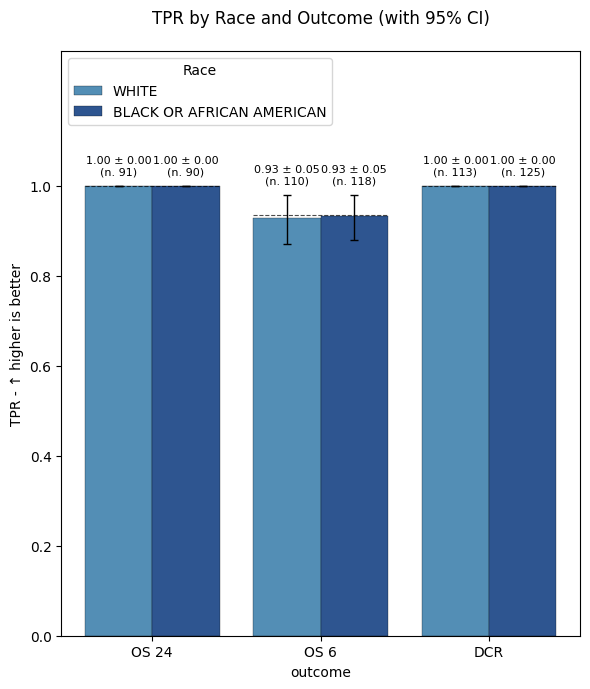

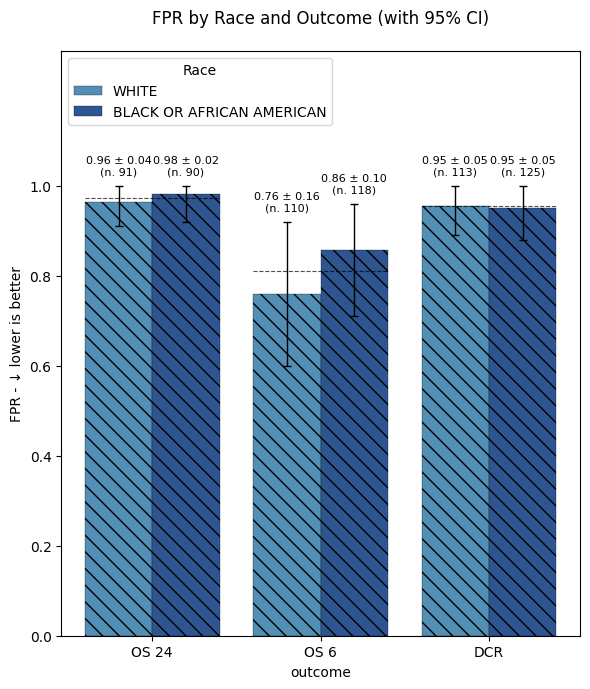

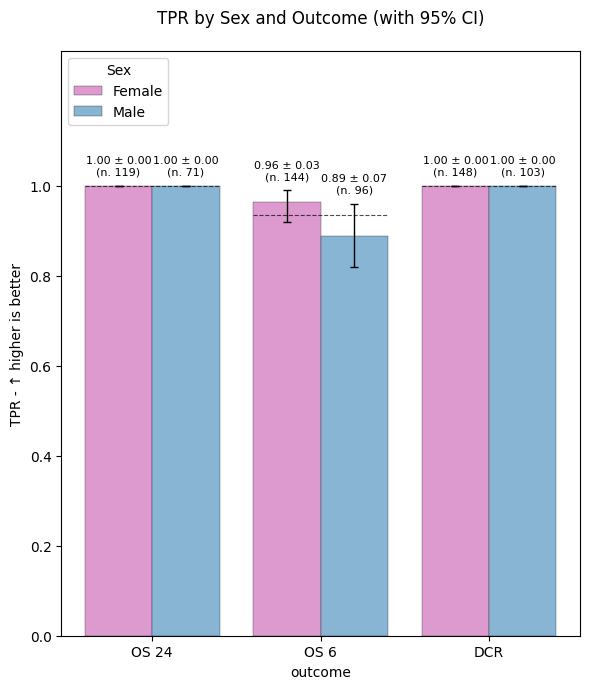

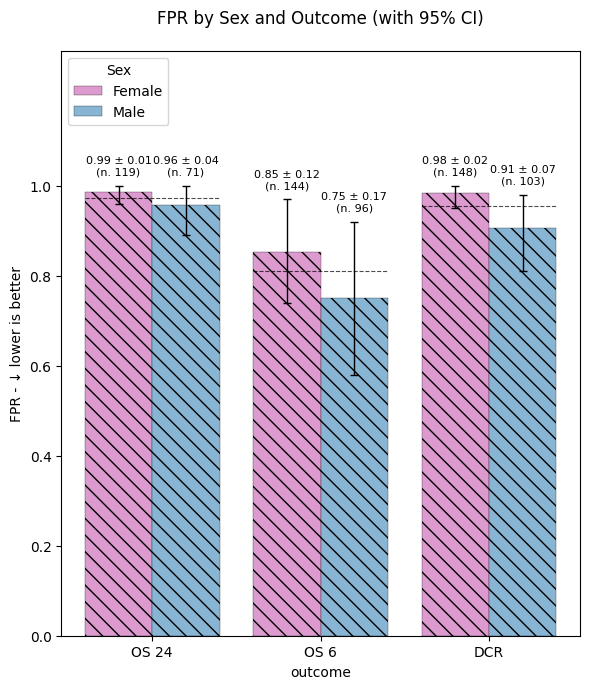

In [ ]:
# Compute patient counts from results
exval_patients_race = {}
exval_patients_sex = {}

for outcome_name, results in exval_results.items():
    if results is None: continue
    exval_patients_race[outcome_name] = results['patients_per_race']
    exval_patients_sex[outcome_name] = results['patients_per_sex']

print("Patients per race (EXVAL):")
for outcome, counts in exval_patients_race.items():
    print(f"  {outcome}: {counts}")



sex_map = {0: "Female", 1: "Male"}

for outcome in exval_patients_sex:
    exval_patients_sex[outcome] = {
        sex_map[k]: v for k, v in exval_patients_sex[outcome].items()
    }
    
print("\nPatients per sex (EXVAL):")
for outcome, counts in exval_patients_sex.items():
    print(f"  {outcome}: {counts}")
# Plot TPR by race (EXVAL)
plot_fairness_by_group(
    fairness_df=race_fairness_summary,
    metric='TPR',
    group_col='Race',
    patients_per_outcome=exval_patients_race,
    outcome_thresholds=OUTCOME_THRESHOLDS_TPR
)

# Plot FPR by race (EXVAL)
plot_fairness_by_group(
    fairness_df=race_fairness_summary,
    metric='FPR',
    group_col='Race',
    patients_per_outcome=exval_patients_race,
    outcome_thresholds=OUTCOME_THRESHOLDS_FPR
)

# Plot TPR by sex (EXVAL)
plot_fairness_by_group(
    fairness_df=sex_fairness_summary,
    metric='TPR',
    group_col='Sex',
    patients_per_outcome=exval_patients_sex,
    outcome_thresholds=OUTCOME_THRESHOLDS_TPR
)

# Plot FPR by sex (EXVAL)
plot_fairness_by_group(
    fairness_df=sex_fairness_summary,
    metric='FPR',
    group_col='Sex',
    patients_per_outcome=exval_patients_sex,
    outcome_thresholds=OUTCOME_THRESHOLDS_FPR
)